实验题目：   编程实现误差逆传播算法（BP算法）
实验目的：   掌握误差逆传播算法（BP算法）的工作流程
实验环境（硬件和软件）   Anaconda/Jupyter notebook/Pycharm
实验内容：
编码实现标准BP算法，在西瓜数据集3.0上用这个算法训练一个单隐层网络，并进行测试。
要求：
一、已经给定部分代码，补充完整的代码，需要补充代码的地方已经用红色字体标注，在第（2）部分，包括：
#补充前向传播代码
#补充反向传播代码
#补充参数更新代码
#补充Loss可视化代码
二、将补充完整的第（2）部分的代码提交，并提交实验结果；（也可以自己重写这部分的代码提交）

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

seed = 2020
import random

np.random.seed(seed)  # Numpy module.
random.seed(seed)  # Python random module.

plt.rcParams['font.sans-serif'] = ['SimHei'] #用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False #用来正常显示负号
plt.close('all')

In [2]:
# （1）数据预处理
def preprocess(data):
    #将非数映射数字
    for title in data.columns:
        if data[title].dtype=='object':
            encoder = LabelEncoder()
            data[title] = encoder.fit_transform(data[title])

    #去均值和方差归一化
    ss = StandardScaler()
    X = data.drop('好瓜',axis=1)
    Y = data['好瓜']
    X = ss.fit_transform(X)
    x,y = np.array(X),np.array(Y).reshape(Y.shape[0],1)
    return x,y

#定义Sigmoid
def sigmoid(x):
    return 1/(1+np.exp(-x))

#求导
def d_sigmoid(x):
    return x*(1-x)

In [3]:
# （2）标准BP算法
def standard_BP(x,y,dim=10,eta=0.8,max_iter=500):
    n_samples = 1

    w1 = np.random.random((x.shape[1],dim))
    w2 = np.random.random((dim,1))

    b1 = np.random.random((n_samples,dim))
    b2 = np.random.random((n_samples,1))

    losslist = []
    for ite in range(max_iter):
        loss_per_ite = []
        for m in range(x.shape[0]):
            xi,yi = x[m,:],y[m,:]
            xi,yi = xi.reshape(1,xi.shape[0]),yi.reshape(1,yi.shape[0])

            ##补充前向传播代码
            # 隐层计算
            u1 = np.dot(xi, w1) + b1
            out1 = sigmoid(u1)  # 隐层输出 (1, dim)
            # 输出层计算
            u2 = np.dot(out1, w2) + b2
            out2 = sigmoid(u2)  # 最终输出 (1, 1)

            loss = np.square(yi - out2)/2
            loss_per_ite.append(loss)
            print('iter:%d  loss:%.4f'%(ite,loss))

            ##反向传播
            ##补充反向传播代码
            # 1. 计算输出层误差信号 delta_k
            delta_k = (out2 - yi) * d_sigmoid(out2)  # (1, 1)

            # 2. 计算隐层误差信号 delta_j
            delta_j = np.dot(delta_k, w2.T) * d_sigmoid(out1)  # (1, dim)

            # 3. 计算梯度
            grad_w2 = np.dot(out1.T, delta_k)  # (dim, 1)
            grad_b2 = delta_k  # (1, 1)

            grad_w1 = np.dot(xi.T, delta_j)  # (num_features, dim)
            grad_b1 = delta_j  # (1, dim)

            ##补充参数更新代码
            w1 -= eta * grad_w1
            b1 -= eta * grad_b1
            w2 -= eta * grad_w2
            b2 -= eta * grad_b2

        losslist.append(np.mean(loss_per_ite))

    ##Loss可视化
    plt.figure()

    ##补充Loss可视化代码
    plt.plot(range(max_iter), losslist)
    plt.xlabel('迭代次数')
    plt.ylabel('平均损失')
    plt.title('标准BP算法 损失下降曲线')
    plt.grid(True)
    plt.show()

    return w1,w2,b1,b2

C:\Users\27341\AppData\Local\Temp\ipykernel_2856\3127015172.py:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('iter:%d  loss:%.4f'%(ite,loss))


iter:0  loss:0.0000
iter:0  loss:0.0003
iter:0  loss:0.0006
iter:0  loss:0.0002
iter:0  loss:0.0006
iter:0  loss:0.0000
iter:0  loss:0.0000
iter:0  loss:0.0023
iter:0  loss:0.4685
iter:0  loss:0.4838
iter:0  loss:0.2624
iter:0  loss:0.4244
iter:0  loss:0.4769
iter:0  loss:0.4364
iter:0  loss:0.4720
iter:0  loss:0.3335
iter:0  loss:0.4727
iter:1  loss:0.0005
iter:1  loss:0.0030
iter:1  loss:0.0062
iter:1  loss:0.0025
iter:1  loss:0.0067
iter:1  loss:0.0005
iter:1  loss:0.0006
iter:1  loss:0.0162
iter:1  loss:0.4094
iter:1  loss:0.4264
iter:1  loss:0.1330
iter:1  loss:0.2707
iter:1  loss:0.3493
iter:1  loss:0.2321
iter:1  loss:0.2314
iter:1  loss:0.0523
iter:1  loss:0.0943
iter:2  loss:0.2569
iter:2  loss:0.1013
iter:2  loss:0.0992
iter:2  loss:0.0482
iter:2  loss:0.0604
iter:2  loss:0.0153
iter:2  loss:0.0126
iter:2  loss:0.0667
iter:2  loss:0.3103
iter:2  loss:0.2702
iter:2  loss:0.0506
iter:2  loss:0.1015
iter:2  loss:0.1346
iter:2  loss:0.0832
iter:2  loss:0.0644
iter:2  loss:0.0184


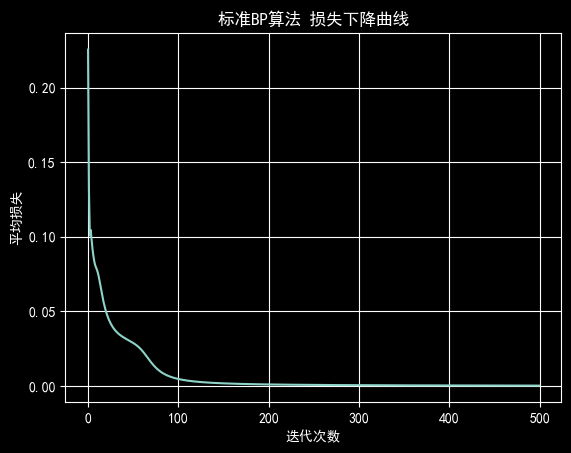

In [4]:
# （3）测试
data = pd.read_table('watermelon30.txt',delimiter=',')
data.drop('编号',axis=1,inplace=True)

x,y = preprocess(data)

dim = 10
w1,w2,b1,b2 = standard_BP(x,y,dim)

#根据当前的x，预测其类别；
u1 = np.dot(x,w1)+b1
out1 = sigmoid(u1)

u2 = np.dot(out1,w2)+b2
out2 = sigmoid(u2)
y_pred = np.round(out2)

result = pd.DataFrame(np.hstack((y,y_pred)),columns=['真值','预测'] )
result.to_excel('result.xlsx',index=False)

C:\Users\27341\AppData\Local\Temp\ipykernel_2856\1168846602.py:55: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('iter:%d  loss:%.4f'%(ite,loss))


iter:0  loss:0.0000
iter:0  loss:0.0003
iter:0  loss:0.0006
iter:0  loss:0.0002
iter:0  loss:0.0006
iter:0  loss:0.0000
iter:0  loss:0.0000
iter:0  loss:0.0023
iter:0  loss:0.4685
iter:0  loss:0.4838
iter:0  loss:0.2624
iter:0  loss:0.4244
iter:0  loss:0.4769
iter:0  loss:0.4364
iter:0  loss:0.4720
iter:0  loss:0.3335
iter:0  loss:0.4727
iter:1  loss:0.0005
iter:1  loss:0.0030
iter:1  loss:0.0062
iter:1  loss:0.0025
iter:1  loss:0.0067
iter:1  loss:0.0005
iter:1  loss:0.0006
iter:1  loss:0.0162
iter:1  loss:0.4094
iter:1  loss:0.4264
iter:1  loss:0.1330
iter:1  loss:0.2707
iter:1  loss:0.3493
iter:1  loss:0.2321
iter:1  loss:0.2314
iter:1  loss:0.0523
iter:1  loss:0.0943
iter:2  loss:0.2569
iter:2  loss:0.1013
iter:2  loss:0.0992
iter:2  loss:0.0482
iter:2  loss:0.0604
iter:2  loss:0.0153
iter:2  loss:0.0126
iter:2  loss:0.0667
iter:2  loss:0.3103
iter:2  loss:0.2702
iter:2  loss:0.0506
iter:2  loss:0.1015
iter:2  loss:0.1346
iter:2  loss:0.0832
iter:2  loss:0.0644
iter:2  loss:0.0184


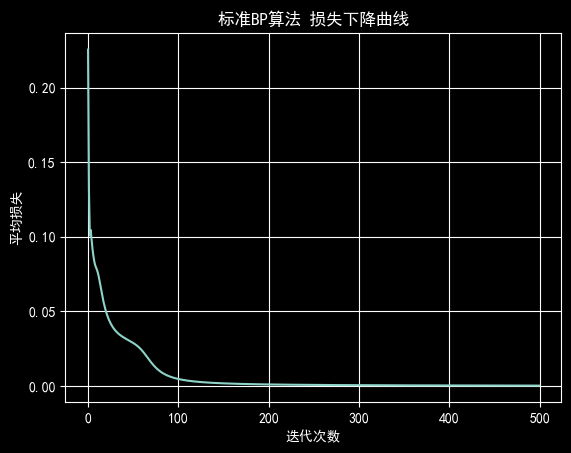

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
seed = 2020
import random
np.random.seed(seed)  # Numpy module.
random.seed(seed)  # Python random module.

plt.rcParams['font.sans-serif'] = ['SimHei'] #用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False #用来正常显示负号
plt.close('all')
# （1）数据预处理
def preprocess(data):
    #将非数映射数字
    for title in data.columns:
        if data[title].dtype=='object':
            encoder = LabelEncoder()
            data[title] = encoder.fit_transform(data[title])
    #去均值和方差归一化
    ss = StandardScaler()
    X = data.drop('好瓜',axis=1)
    Y = data['好瓜']
    X = ss.fit_transform(X)
    x,y = np.array(X),np.array(Y).reshape(Y.shape[0],1)
    return x,y
#定义Sigmoid
def sigmoid(x):
    return 1/(1+np.exp(-x))
#求导
def d_sigmoid(x):
    return x*(1-x)
# （2）标准BP算法
def standard_BP(x,y,dim=10,eta=0.8,max_iter=500):
    n_samples = 1
    w1 = np.random.random((x.shape[1],dim))
    w2 = np.random.random((dim,1))
    b1 = np.random.random((n_samples,dim))
    b2 = np.random.random((n_samples,1))
    losslist = []
    for ite in range(max_iter):
        loss_per_ite = []
        for m in range(x.shape[0]):
            xi,yi = x[m,:],y[m,:]
            xi,yi = xi.reshape(1,xi.shape[0]),yi.reshape(1,yi.shape[0])
            ##补充前向传播代码
            u1 = np.dot(xi, w1) + b1
            out1 = sigmoid(u1)  # 隐层输出 (1, dim)
            u2 = np.dot(out1, w2) + b2
            out2 = sigmoid(u2)  # 最终输出 (1, 1)

            loss = np.square(yi - out2)/2
            loss_per_ite.append(loss)
            print('iter:%d  loss:%.4f'%(ite,loss))
            ##反向传播
            ##补充反向传播代码
            delta_k = (out2 - yi) * d_sigmoid(out2)  # (1, 1)

            delta_j = np.dot(delta_k, w2.T) * d_sigmoid(out1)  # (1, dim)

            grad_w2 = np.dot(out1.T, delta_k)  # (dim, 1)
            grad_b2 = delta_k  # (1, 1)

            grad_w1 = np.dot(xi.T, delta_j)  # (num_features, dim)
            grad_b1 = delta_j  # (1, dim)


            ##补充参数更新代码
            w1 -= eta * grad_w1
            b1 -= eta * grad_b1
            w2 -= eta * grad_w2
            b2 -= eta * grad_b2


        losslist.append(np.mean(loss_per_ite))
    ##Loss可视化
    plt.figure()
    ##补充Loss可视化代码
    plt.plot(range(max_iter), losslist)
    plt.xlabel('迭代次数')
    plt.ylabel('平均损失')
    plt.title('标准BP算法 损失下降曲线')
    plt.grid(True)
    plt.show()

    return w1,w2,b1,b2
# （3）测试
data = pd.read_table('watermelon30.txt',delimiter=',')
data.drop('编号',axis=1,inplace=True)
x,y = preprocess(data)
dim = 10
w1,w2,b1,b2 = standard_BP(x,y,dim)
#根据当前的x，预测其类别；
u1 = np.dot(x,w1)+b1
out1 = sigmoid(u1)
u2 = np.dot(out1,w2)+b2
out2 = sigmoid(u2)
y_pred = np.round(out2)
result = pd.DataFrame(np.hstack((y,y_pred)),columns=['真值','预测'] )
result.to_excel('result.xlsx',index=False)
